SEASON BATTING AGGREGATION

In [2]:
import pandas as pd

balls = pd.read_csv("ipl_ball_by_ball_clean.csv")
matches = pd.read_csv("ipl_matches.csv")

print(balls.shape)
print(matches.shape)

C:\Users\acer\AppData\Local\Temp\ipykernel_9220\3334608482.py:3: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  balls = pd.read_csv("ipl_ball_by_ball_clean.csv")


(288226, 50)
(1212, 19)


In [3]:
bat_s = balls.groupby(['season','batter']).agg(
    runs=('batter_runs','sum'),
    balls_faced=('batter','count'),
    innings=('match_id','nunique'),
    fours=('is_boundary_4','sum'),
    sixes=('is_boundary_6','sum')
).reset_index()

bat_s.head()

,season,batter,runs,balls_faced,innings,fours,sixes
0,2011,A Mishra,54,44,7,8,0
1,2011,A Mithun,27,20,4,3,1
2,2011,A Singh,1,4,2,0,0
3,2011,A Symonds,135,143,9,9,3
4,2011,AA Chavan,1,3,1,0,0


In [4]:
dismissals = (
    balls[balls['wicket_player_out'].notna()]
    .groupby(['season','wicket_player_out'])
    .size()
    .reset_index(name='dismissals')
)

dismissals.head()

,season,wicket_player_out,dismissals
0,2011,A Mishra,4
1,2011,A Mithun,3
2,2011,A Singh,2
3,2011,A Symonds,4
4,2011,AA Chavan,1


In [ ]:
dismissals = (
    balls[balls['wicket_player_out'].notna()]
    .groupby(['season','wicket_player_out'])
    .size()
    .reset_index(name='dismissals')
)

In [5]:
import numpy as np

bat_s = bat_s.merge(
    dismissals,
    left_on=['season','batter'],
    right_on=['season','wicket_player_out'],
    how='left'
)

bat_s['dismissals'] = bat_s['dismissals'].fillna(0)

bat_s['average'] = (
    bat_s['runs'] /
    bat_s['dismissals'].replace(0,np.nan)
)

bat_s['strike_rate'] = (
    bat_s['runs'] /
    bat_s['balls_faced'] * 100
)

bat_s['boundary_pct'] = (
    (bat_s['fours'] + bat_s['sixes']) /
    bat_s['balls_faced'] * 100
)

print(bat_s.columns)

Index(['season', 'batter', 'runs', 'balls_faced', 'innings', 'fours', 'sixes',
       'wicket_player_out', 'dismissals', 'average', 'strike_rate',
       'boundary_pct'],
      dtype='str')



SEASON LEVEL NORMALISATION

In [6]:
bat_s['avg_norm'] = (
    bat_s['average'] - bat_s['average'].min()
) / (
    bat_s['average'].max() - bat_s['average'].min()
)

bat_s['sr_norm'] = (
    bat_s['strike_rate'] - bat_s['strike_rate'].min()
) / (
    bat_s['strike_rate'].max() - bat_s['strike_rate'].min()
)

bat_s['boundary_norm'] = (
    bat_s['boundary_pct'] - bat_s['boundary_pct'].min()
) / (
    bat_s['boundary_pct'].max() - bat_s['boundary_pct'].min()
)

bat_s.head()

,season,batter,runs,balls_faced,innings,fours,sixes,wicket_player_out,dismissals,average,strike_rate,boundary_pct,avg_norm,sr_norm,boundary_norm
0,2011,A Mishra,54,44,7,8,0,A Mishra,4.0,13.50,122.727273,18.181818,0.082822,0.306818,0.181818
1,2011,A Mithun,27,20,4,3,1,A Mithun,3.0,9.00,135.000000,20.000000,0.055215,0.337500,0.200000
2,2011,A Singh,1,4,2,0,0,A Singh,2.0,0.50,25.000000,0.000000,0.003067,0.062500,0.000000
3,2011,A Symonds,135,143,9,9,3,A Symonds,4.0,33.75,94.405594,8.391608,0.207055,0.236014,0.083916
4,2011,AA Chavan,1,3,1,0,0,AA Chavan,1.0,1.00,33.333333,0.000000,0.006135,0.083333,0.000000


BATTING AGGREGATION

In [7]:
bat_s['bat_index'] = (
    bat_s['avg_norm'] * 0.4 +
    bat_s['sr_norm'] * 0.4 +
    bat_s['boundary_norm'] * 0.2
)

bat_s.head()

,season,batter,runs,balls_faced,innings,fours,sixes,wicket_player_out,dismissals,average,strike_rate,boundary_pct,avg_norm,sr_norm,boundary_norm,bat_index
0,2011,A Mishra,54,44,7,8,0,A Mishra,4.0,13.50,122.727273,18.181818,0.082822,0.306818,0.181818,0.192220
1,2011,A Mithun,27,20,4,3,1,A Mithun,3.0,9.00,135.000000,20.000000,0.055215,0.337500,0.200000,0.197086
2,2011,A Singh,1,4,2,0,0,A Singh,2.0,0.50,25.000000,0.000000,0.003067,0.062500,0.000000,0.026227
3,2011,A Symonds,135,143,9,9,3,A Symonds,4.0,33.75,94.405594,8.391608,0.207055,0.236014,0.083916,0.194011
4,2011,AA Chavan,1,3,1,0,0,AA Chavan,1.0,1.00,33.333333,0.000000,0.006135,0.083333,0.000000,0.035787


BEST BATTER PER SEASON TABLE

In [8]:
best_batter = (
    bat_s.sort_values(
        ['season','bat_index'],
        ascending=[True,False]
    )
    .groupby('season')
    .head(1)
)

best_batter[
    ['season','batter','runs','average','strike_rate','bat_index']
]

,season,batter,runs,average,strike_rate,bat_index
33,2011,CH Gayle,608,67.555556,177.777778,0.402623
209,2012,CH Gayle,733,61.083333,155.296610,0.349686
472,2013,R Vinay Kumar,70,70.000000,159.090909,0.371779
591,2014,MS Dhoni,371,74.200000,143.798450,0.358442
697,2015,JA Morkel,86,86.000000,122.857143,0.365329
908,2016,V Kohli,973,81.083333,148.549618,0.384779
939,2017,CA Lynn,295,49.166667,168.571429,0.339512
1068,2018,Abhishek Sharma,63,63.000000,180.000000,0.380316
1242,2019,MS Dhoni,156,156.000000,118.181818,0.525246
1320,2021,J Yadav,11,11.000000,275.000000,0.401994


Bowling Aggregation

In [9]:
bowl_s = balls.groupby(['season','bowler']).agg(
    balls_bowled=('legal_ball','sum'),
    runs_conceded=('total_runs','sum'),
    wickets=('wicket_count','sum')
).reset_index()

bowl_s.head()

,season,bowler,balls_bowled,runs_conceded,wickets
0,2011,A Mishra,248,280,16
1,2011,A Mithun,180,275,6
2,2011,A Singh,108,142,5
3,2011,A Symonds,24,41,1
4,2011,AA Chavan,30,31,0


In [10]:
bowl_s['overs'] = bowl_s['balls_bowled'] / 6

bowl_s['economy'] = (
    bowl_s['runs_conceded'] /
    bowl_s['overs']
)

bowl_s.head()

,season,bowler,balls_bowled,runs_conceded,wickets,overs,economy
0,2011,A Mishra,248,280,16,41.333333,6.774194
1,2011,A Mithun,180,275,6,30.000000,9.166667
2,2011,A Singh,108,142,5,18.000000,7.888889
3,2011,A Symonds,24,41,1,4.000000,10.250000
4,2011,AA Chavan,30,31,0,5.000000,6.200000


In [11]:
dots = balls.groupby(
    ['season','bowler']
)['is_dot_ball'].sum().reset_index()

bowl_s = bowl_s.merge(
    dots,
    on=['season','bowler'],
    how='left'
)

bowl_s['dot_pct'] = (
    bowl_s['is_dot_ball'] /
    bowl_s['balls_bowled'] * 100
)

bowl_s.head()

,season,bowler,balls_bowled,runs_conceded,wickets,overs,economy,is_dot_ball,dot_pct
0,2011,A Mishra,248,280,16,41.333333,6.774194,103,41.532258
1,2011,A Mithun,180,275,6,30.000000,9.166667,61,33.888889
2,2011,A Singh,108,142,5,18.000000,7.888889,41,37.962963
3,2011,A Symonds,24,41,1,4.000000,10.250000,10,41.666667
4,2011,AA Chavan,30,31,0,5.000000,6.200000,17,56.666667


In [12]:
bowl_s_q = bowl_s[
    bowl_s['balls_bowled'] >= 60
].copy()

print(bowl_s_q.shape)

(1481, 9)


In [14]:
bowl_s_q['wicket_norm'] = bowl_s_q.groupby('season')['wickets'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

bowl_s_q['eco_norm'] = bowl_s_q.groupby('season')['economy'].transform(
    lambda x: 1 - ((x - x.min()) / (x.max() - x.min()))
)

bowl_s_q['dot_norm'] = bowl_s_q.groupby('season')['dot_pct'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [15]:
bowl_s_q['bowl_index'] = (
    0.5 * bowl_s_q['wicket_norm'] +
    0.3 * bowl_s_q['eco_norm'] +
    0.2 * bowl_s_q['dot_norm']
)

bowl_s_q.head()

,season,bowler,balls_bowled,runs_conceded,wickets,overs,economy,is_dot_ball,dot_pct,wicket_norm,eco_norm,dot_norm,bowl_index
0,2011,A Mishra,248,280,16,41.333333,6.774194,103,41.532258,0.714286,0.719714,0.671053,0.707268
1,2011,A Mithun,180,275,6,30.000000,9.166667,61,33.888889,0.238095,0.163685,0.421637,0.252481
2,2011,A Singh,108,142,5,18.000000,7.888889,41,37.962963,0.190476,0.460650,0.554581,0.344349
7,2011,AB Agarkar,162,236,9,27.000000,8.740741,46,28.395062,0.380952,0.262673,0.242365,0.317751
8,2011,AB Dinda,69,113,4,11.500000,9.826087,25,36.231884,0.142857,0.010431,0.498093,0.174176


In [16]:
best_bowler = (
    bowl_s_q.sort_values(
        ['season','bowl_index'],
        ascending=[True, False]
    )
    .groupby('season')
    .head(1)
)

best_bowler[
    ['season','bowler','wickets','economy','dot_pct','bowl_index']
]

,season,bowler,wickets,economy,dot_pct,bowl_index
106,2011,SL Malinga,21,5.941558,47.077922,0.920561
235,2012,SP Narine,29,5.611268,46.197183,0.957374
371,2013,SP Narine,26,5.515625,46.875000,0.837710
393,2014,B Kumar,21,6.808777,47.648903,0.858701
489,2015,A Nehra,25,7.306452,45.698925,0.839773
597,2016,B Kumar,24,7.621212,39.393939,0.880491
734,2017,JD Unadkat,27,7.200000,43.272727,0.854110
874,2018,Rashid Khan,23,6.852941,39.705882,0.785714
937,2019,Mohammad Nabi,7,4.250000,44.444444,0.786911
996,2021,HV Patel,15,7.343284,38.059701,0.781733


MULTI-PLAYER TREND LINE CHARTS

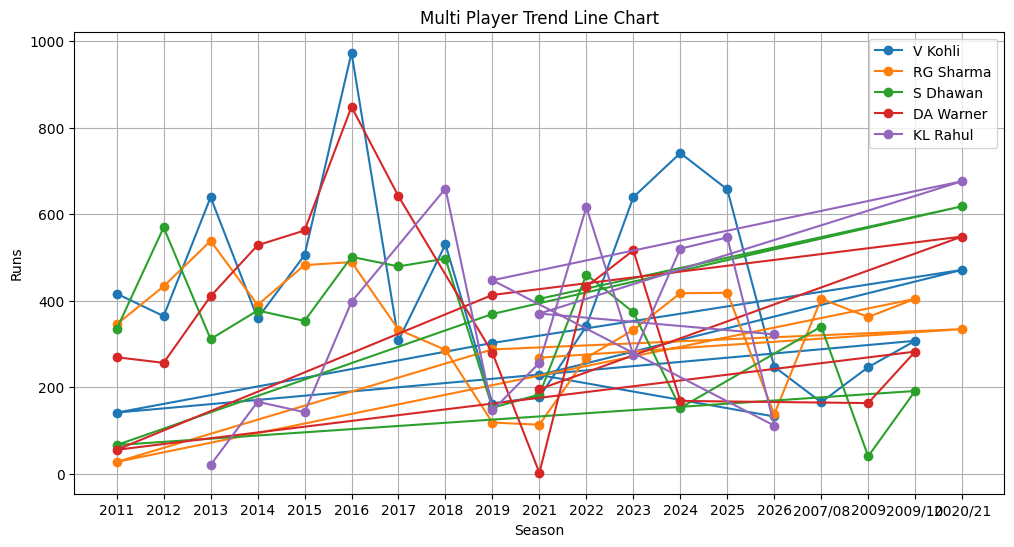

In [17]:
import matplotlib.pyplot as plt

top5 = (
    bat_s.groupby('batter')['runs']
    .sum()
    .nlargest(5)
    .index
)

trend_plot = bat_s[
    bat_s['batter'].isin(top5)
].copy()

trend_plot = trend_plot.dropna(subset=['season','runs'])

trend_plot['season'] = trend_plot['season'].astype(str)

plt.figure(figsize=(12,6))

for player in top5:
    temp = trend_plot[
        trend_plot['batter'] == player
    ]

    plt.plot(
        temp['season'],
        temp['runs'],
        marker='o',
        label=player
    )

plt.legend()
plt.xlabel('Season')
plt.ylabel('Runs')
plt.title('Multi Player Trend Line Chart')
plt.grid(True)

plt.show()

IDENTIFY THE BEST IPL ALL ROUNDERS BY COMBINING BATTING AND BOWLING PERFORMANCE

In [18]:
all_rounders = bat_s.merge(
    bowl_s_q,
    left_on=['season','batter'],
    right_on=['season','bowler'],
    how='inner'
)

print(all_rounders.shape)

(1288, 28)


In [19]:
all_rounders['all_rounder_index'] = (
    0.5 * all_rounders['bat_index'] +
    0.5 * all_rounders['bowl_index']
)

In [20]:
all_rounders_rank = (
    all_rounders
    .sort_values(
        ['season','all_rounder_index'],
        ascending=[True,False]
    )
)

all_rounders_rank[
    [
        'season',
        'batter',
        'bat_index',
        'bowl_index',
        'all_rounder_index'
    ]
].head(20)

,season,batter,bat_index,bowl_index,all_rounder_index
61,2011,SL Malinga,0.117655,0.920561,0.519108
45,2011,R Sharma,0.161452,0.792231,0.476841
0,2011,A Mishra,0.192220,0.707268,0.449744
19,2011,Harbhajan Singh,0.263983,0.632962,0.448473
11,2011,CH Gayle,0.402623,0.476153,0.439388
43,2011,R Ashwin,0.035787,0.833415,0.434601
69,2011,YK Pathan,0.254088,0.592597,0.423342
34,2011,M Morkel,0.315551,0.528836,0.422193
36,2011,MM Patel,0.000000,0.834849,0.417424
42,2011,PP Chawla,0.192343,0.581437,0.386890


In [ ]:
best_all_rounder = (
    all_rounders_rank
    .groupby('season')
    .head(1)
)

best_all_rounder[
    [
        'season',
        'batter',
        'all_rounder_index'
    ]
]

,season,batter,all_rounder_index
61,2011,SL Malinga,0.519108
135,2012,SP Narine,0.570980
160,2013,DW Steyn,0.494811
215,2014,AR Patel,0.468754
308,2015,MJ McClenaghan,0.477902
345,2016,CH Morris,0.553770
404,2017,B Kumar,0.470962
511,2018,Rashid Khan,0.527648
527,2019,AD Russell,0.432502
569,2021,HV Patel,0.458530


In [22]:
all_rounders = bat_s.merge(
    bowl_s_q,
    left_on=['season','batter'],
    right_on=['season','bowler'],
    how='inner'
)

all_rounders = all_rounders[
    (all_rounders['innings'] >= 5) &
    (all_rounders['runs'] >= 150) &
    (all_rounders['balls_bowled'] >= 60)
].copy()

all_rounders['all_rounder_index'] = (
    0.5 * all_rounders['bat_index'] +
    0.5 * all_rounders['bowl_index']
)

all_rounders_rank = (
    all_rounders
    .sort_values(
        ['season','all_rounder_index'],
        ascending=[True,False]
    )
)

best_all_rounder = (
    all_rounders_rank
    .groupby('season')
    .head(1)
)

print("Best All-Rounder Per Season")
print(
    best_all_rounder[
        ['season','batter','bat_index','bowl_index','all_rounder_index']
    ]
)

print("\nTop 20 All-Rounders")
print(
    all_rounders_rank[
        ['season','batter','bat_index','bowl_index','all_rounder_index']
    ].head(20)
)

Best All-Rounder Per Season
       season           batter  bat_index  bowl_index  all_rounder_index
11       2011         CH Gayle   0.402623    0.476153           0.439388
90       2012         DJ Bravo   0.280224    0.591099           0.435662
205      2013        SR Watson   0.274569    0.523141           0.398855
263      2014  Shakib Al Hasan   0.249620    0.678682           0.464151
284      2015         DJ Bravo   0.218070    0.735807           0.476939
345      2016        CH Morris   0.377930    0.729609           0.553770
405      2017        BA Stokes   0.249352    0.598381           0.423866
516      2018        SP Narine   0.298694    0.595084           0.446889
568      2021       GJ Maxwell   0.316055    0.244430           0.280242
594      2022       AD Russell   0.308843    0.522625           0.415734
720      2023        RA Jadeja   0.224949    0.639814           0.432382
788      2024        SP Narine   0.309512    0.681034           0.495273
854      2025        SP

Created an interactive dashboard using plotly

In [23]:
import pandas as pd

ball = pd.read_csv("ipl_ball_by_ball.csv")

batting = ball.groupby('batter').agg(
    runs=('batter_runs', 'sum'),
    balls=('ball_number', 'count'),
    innings=('match_id', 'nunique')
).reset_index()

batting['bat_index'] = batting['runs'] / batting['innings']

C:\Users\acer\AppData\Local\Temp\ipykernel_9220\1639679816.py:3: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  ball = pd.read_csv("ipl_ball_by_ball.csv")


In [24]:
bowling = ball.groupby('bowler').agg(
    balls=('ball_number', 'count'),
    wickets=('is_wicket', 'sum')
).reset_index()

bowling['bowl_index'] = bowling['wickets'] / bowling['balls']

In [25]:
import pandas as pd

balls = pd.read_csv("ipl_ball_by_ball_clean.csv")
matches = pd.read_csv("ipl_matches.csv")

C:\Users\acer\AppData\Local\Temp\ipykernel_9220\2484343578.py:3: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  balls = pd.read_csv("ipl_ball_by_ball_clean.csv")


In [26]:
batting_qual = bat_s.copy()
bowling_qual = bowl_s_q.copy()

In [27]:
all_rounders = batting_qual.merge(
    bowling_qual,
    left_on='batter',
    right_on='bowler',
    how='inner'
)

In [28]:
print(all_rounders.columns.tolist())

['season_x', 'batter', 'runs', 'balls_faced', 'innings', 'fours', 'sixes', 'wicket_player_out', 'dismissals', 'average', 'strike_rate', 'boundary_pct', 'avg_norm', 'sr_norm', 'boundary_norm', 'bat_index', 'season_y', 'bowler', 'balls_bowled', 'runs_conceded', 'wickets', 'overs', 'economy', 'is_dot_ball', 'dot_pct', 'wicket_norm', 'eco_norm', 'dot_norm', 'bowl_index']


In [29]:
all_rounders['all_rounder_index'] = (
    all_rounders['bat_index'] * 0.6 +
    all_rounders['bowl_index'] * 0.4
)

all_rounders[['batter','all_rounder_index']].head()

,batter,all_rounder_index
0,A Mishra,0.398239
1,A Mishra,0.304486
2,A Mishra,0.404272
3,A Mishra,0.261313
4,A Mishra,0.293958


VISUALISE ALL ROUNDERS

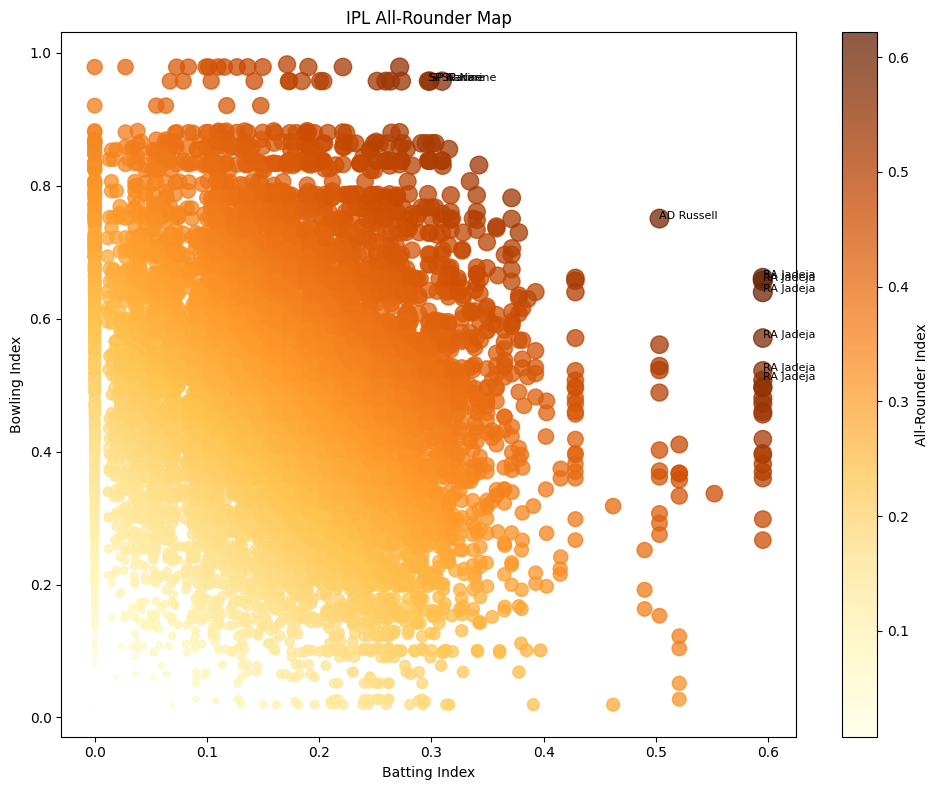

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    all_rounders['bat_index'],
    all_rounders['bowl_index'],
    s=all_rounders['all_rounder_index'] * 300,
    c=all_rounders['all_rounder_index'],
    cmap='YlOrBr',
    alpha=0.75
)

plt.colorbar(sc, ax=ax, label='All-Rounder Index')

for _, row in all_rounders.nlargest(10, 'all_rounder_index').iterrows():
    ax.annotate(
        row['batter'],
        (row['bat_index'], row['bowl_index']),
        fontsize=8
    )

ax.set_title('IPL All-Rounder Map')
ax.set_xlabel('Batting Index')
ax.set_ylabel('Bowling Index')

plt.tight_layout()
plt.show()

In [31]:
bat_s_q = ball.groupby(['season','batter']).agg(
    runs=('batter_runs','sum'),
    balls=('ball_number','count'),
    innings=('match_id','nunique')
).reset_index()

bat_s_q['bat_index'] = bat_s_q['runs'] / bat_s_q['innings']

Career Rankings Bar Chart

In [32]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

os.makedirs("outputs", exist_ok=True)

top_bat15 = batting_qual.nlargest(15,'bat_index')
top_bowl15 = bowling_qual.nlargest(15,'bowl_index')

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Top 15 Batsmen","Top 15 Bowlers")
)

fig.add_trace(
    go.Bar(
        x=top_bat15['bat_index'],
        y=top_bat15['batter'],
        orientation='h'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=top_bowl15['bowl_index'],
        y=top_bowl15['bowler'],
        orientation='h'
    ),
    row=1,
    col=2
)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    title="IPL Career Rankings Dashboard",
    height=500,
    showlegend=False
)

fig.write_html("outputs/dashboard_career.html")
fig.show()

Season Trend with dropdown

In [33]:
import plotly.graph_objects as go

players = batting_qual.nlargest(10,'bat_index')['batter'].tolist()

df = bat_s_q[bat_s_q['batter'].isin(players)]

In [34]:
import plotly.graph_objects as go
import os

os.makedirs("outputs", exist_ok=True)

players = batting_qual.nlargest(10,'bat_index')['batter'].tolist()
trend_data = bat_s_q[bat_s_q['batter'].isin(players)]

fig = go.Figure()

for i, p in enumerate(players):
    temp = trend_data[trend_data['batter'] == p]

    fig.add_trace(go.Scatter(
        x=temp['season'],
        y=temp['bat_index'],
        mode='lines+markers',
        name=p,
        visible=(i == 0)
    ))

buttons = []

for i, p in enumerate(players):
    vis = [False] * len(players)
    vis[i] = True

    buttons.append(dict(
        label=p,
        method="update",
        args=[
            {"visible": vis},
            {"title": f"Batting Trend — {p}"}
        ]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down"
    )],
    xaxis_title="Season",
    yaxis_title="Batting Index",
    title="Batting Index Season Trend (Dropdown View)",
    height=550
)

fig.write_html("outputs/dashboard_season_trend.html")
fig.show()

SR vs Average Bubble Chart

In [ ]:

import plotly.express as px
import os

os.makedirs("outputs", exist_ok=True)

batting_qual['strike_rate'] = (batting_qual['runs'] / batting_qual['balls_faced']) * 100
batting_qual['average'] = batting_qual['runs'] / batting_qual['innings']

fig_bubble = px.scatter(
    batting_qual.nlargest(100,'bat_index'),
    x='strike_rate',
    y='average',
    size='runs',
    color='bat_index',
    hover_name='batter',
    hover_data={
        'runs':True,
        'strike_rate':':.1f',

        
        'average':':.2f',
        'bat_index':':.2f'
    },
    title='Strike Rate vs Average — Top 100 Batsmen',
    labels={
        'strike_rate':'Strike Rate',
        'average':'Batting Average',
        'bat_index':'Batting Index'
    }

    
)

fig_bubble.update_layout(height=550)

fig_bubble.write_html(
    "outputs/dashboard_batting_scatter.html"
)

fig_bubble.show()

In [ ]:
bat_s_q.to_csv('outputs/batting_season_rankings.csv', index=False)
bowl_s_q.to_csv('outputs/bowling_season_rankings.csv', index=False)
all_rounders.to_csv('outputs/allrounder_rankings.csv', index=False)
print('All Week 3 outputs saved.')

All Week 3 outputs saved.


##What you produced this week?
   -Season-wise batting rankings
   -Season-wise bowling rankings
   -All-rounder rankings
   -Interactive visualizations and dashboard views
   -CSV output files.
##One result that surprised you?
    Some lesser-known players ranked higher than expected because of their consistent performances across seasons.
##One limitation of your current approach?
    The analysis focuses only on season-level statistics and does not consider match-by-match performance variations.
##What Week 4 needs to cover?
    -Validation of results
    -Dashboard improvements
    -Final report preparation
    -Project testing and documentation